
# 07 - Comparación de intervalos de predicción

Este notebook compara, sobre el conjunto de validación (2024), los intervalos de predicción obtenidos en los notebooks anteriores:

- Modelo base ingenuo estacional + split conformal (`06a_split_conformal_baseline.ipynb`)
- Regresión lineal + CQR con MAPIE (`06b_cqr_supervised_models.ipynb`)
- LightGBM + CQR con MAPIE (`06b_cqr_supervised_models.ipynb`)
- CatBoost + CQR con MAPIE (`06b_cqr_supervised_models.ipynb`)

Y, por otra parte, genera:

1. Métricas de los intervalos de predicción usando todas las predicciones disponibles
2. Métricas de los intervalos de predicción restringidas a los instantes objetivo que son comunes a todos los métodos
3. Tablas comparativas y una selección preliminar del mejor método por horizonte
4. Figuras relevantes que muestren claramente la comparación buscada.


## Criterio de comparación

La comparación principal del notebook se realizará sobre los instantes objetivo comunes a todos los métodos para cada horizonte. De esta manera, se evita comparar intervalos calculados sobre subconjuntos distintos de observaciones.

Se evaluarán las siguientes métricas, tal y como se ha establecido en la memoria:

- Cobertura empírica
- Aanchura media
- Interval score

In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display


In [ ]:
# Configuración general del notebook
# ==============================================================================
# El notebook puede ejecutarse desde la carpeta notebooks/ o desde la raíz del
# repositorio. Esta función localiza la raíz de forma dinámica.

def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    current = Path.cwd() if start is None else start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "reports").exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. Debe ejecutarse el notebook desde "
        "la raíz del repositorio o desde la carpeta notebooks/."
    )

PROJECT_ROOT = find_project_root()
REPORTS_INTERVALS_DIR = PROJECT_ROOT / "reports" / "intervals"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

for path in [REPORTS_TABLES_DIR, REPORTS_FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

HORIZONS: List[int] = [1, 4, 12, 24]
VALIDATION_SPLIT = "validation"
ALPHA = 0.20
NOMINAL_COVERAGE = 1 - ALPHA
EXAMPLE_HORIZON = 24
EXAMPLE_HOURS = 7 * 24  # una semana continua para la figura de ejemplo

MODEL_REGISTRY: Dict[str, Dict[str, str]] = {
    "baseline_seasonal_naive": {
        "display_name": "Modelo base ingenuo estacional",
        "short_name": "Baseline",
        "interval_prefix": "split_conformal_baseline",
        "method": "split_conformal",
        "method_display": "Split conformal",
        "label": "Baseline + split conformal",
        "color": "tab:gray",
    },
    "linear_regression": {
        "display_name": "Regresión lineal",
        "short_name": "Lineal",
        "interval_prefix": "cqr_linear_regression",
        "method": "cqr_mapie",
        "method_display": "CQR",
        "label": "Regresión lineal + CQR",
        "color": "tab:green",
    },
    "lightgbm": {
        "display_name": "LightGBM",
        "short_name": "LGBM",
        "interval_prefix": "cqr_lightgbm",
        "method": "cqr_mapie",
        "method_display": "CQR",
        "label": "LightGBM + CQR",
        "color": "tab:red",
    },
    "catboost": {
        "display_name": "CatBoost",
        "short_name": "CAT",
        "interval_prefix": "cqr_catboost",
        "method": "cqr_mapie",
        "method_display": "CQR",
        "label": "CatBoost + CQR",
        "color": "tab:purple",
    },
}

MODEL_ORDER = list(MODEL_REGISTRY.keys())
HORIZON_MARKERS = {1: "o", 4: "s", 12: "^", 24: "D"}

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Intervalos: {REPORTS_INTERVALS_DIR}")
print(f"Tablas: {REPORTS_TABLES_DIR}")
print(f"Figuras: {REPORTS_FIGURES_DIR}")
print(f"Cobertura nominal: {NOMINAL_COVERAGE:.0%}")


Raíz del proyecto: c:\trabajo_github
Intervalos: c:\trabajo_github\reports\intervals
Tablas: c:\trabajo_github\reports\tables
Figuras: c:\trabajo_github\reports\figures
Cobertura nominal: 80%


In [ ]:

def interval_score(
    y_true: pd.Series | np.ndarray,
    lower: pd.Series | np.ndarray,
    upper: pd.Series | np.ndarray,
    alpha: float,
) -> np.ndarray:
    """Calcula el interval score para los intervalos centrales."""
    y = np.asarray(y_true, dtype=float)
    l = np.asarray(lower, dtype=float)
    u = np.asarray(upper, dtype=float)

    width = u - l
    lower_penalty = (2 / alpha) * (l - y) * (y < l)
    upper_penalty = (2 / alpha) * (y - u) * (y > u)

    return width + lower_penalty + upper_penalty


def standardize_interval_frame(df: pd.DataFrame, model_id: str, horizon: int) -> pd.DataFrame:
    meta = MODEL_REGISTRY[model_id]
    out = df.copy()

    if "origin_timestamp" in out.columns:
        out["origin_timestamp"] = pd.to_datetime(out["origin_timestamp"])
    if "target_timestamp" in out.columns:
        out["target_timestamp"] = pd.to_datetime(out["target_timestamp"])

    out["model"] = model_id
    out["model_display"] = meta["display_name"]
    out["method"] = meta["method"]
    out["method_display"] = meta["method_display"]
    out["label"] = meta["label"]
    out["short_name"] = meta["short_name"]
    out["color"] = meta["color"]
    out["horizon"] = horizon

    if "split" not in out.columns:
        out["split"] = VALIDATION_SPLIT

    if "interval_width" not in out.columns:
        out["interval_width"] = out["upper"] - out["lower"]

    if "covered" not in out.columns:
        out["covered"] = (out["y_true"] >= out["lower"]) & (out["y_true"] <= out["upper"])

    if "miss_lower" not in out.columns:
        out["miss_lower"] = out["y_true"] < out["lower"]

    if "miss_upper" not in out.columns:
        out["miss_upper"] = out["y_true"] > out["upper"]

    if "interval_score" not in out.columns:
        out["interval_score"] = interval_score(out["y_true"], out["lower"], out["upper"], ALPHA)

    # Columna unificada de predicción puntual de referencia para la figura de ejemplo.
    point_candidates = [
        "y_pred_reference",
        "y_pred_point",
        "y_pred",
        "y_pred_mapie",
        "y_pred_quantile_median",
    ]
    selected_point_col = None
    for candidate in point_candidates:
        if candidate in out.columns:
            selected_point_col = candidate
            break

    if selected_point_col is not None:
        out["y_pred_reference"] = out[selected_point_col]
    else:
        out["y_pred_reference"] = np.nan

    required = ["target_timestamp", "y_true", "lower", "upper"]
    missing = [col for col in required if col not in out.columns]
    if missing:
        raise ValueError(f"Faltan columnas requeridas en {model_id}, h={horizon}: {missing}")

    return out


def compute_interval_metrics(df: pd.DataFrame) -> dict:
    """Resume las métricas de intervalos."""

    coverage = float(df["covered"].mean())
    return {
        "model": df["model"].iloc[0],
        "model_display": df["model_display"].iloc[0],
        "method": df["method"].iloc[0],
        "method_display": df["method_display"].iloc[0],
        "label": df["label"].iloc[0],
        "horizon": int(df["horizon"].iloc[0]),
        "alpha": ALPHA,
        "nominal_coverage": NOMINAL_COVERAGE,
        "n_samples": int(len(df)),
        "empirical_coverage": coverage,
        "coverage_error": coverage - NOMINAL_COVERAGE,
        "coverage_abs_error": abs(coverage - NOMINAL_COVERAGE),
        "mean_width": float(df["interval_width"].mean()),
        "median_width": float(df["interval_width"].median()),
        "mean_interval_score": float(df["interval_score"].mean()),
        "median_interval_score": float(df["interval_score"].median()),
        "miss_lower_rate": float(df["miss_lower"].mean()),
        "miss_upper_rate": float(df["miss_upper"].mean()),
        "target_start": df["target_timestamp"].min(),
        "target_end": df["target_timestamp"].max(),
    }


def select_continuous_block(df: pd.DataFrame, n_hours: int) -> pd.DataFrame:
    """Selecciona el primer bloque continuo de `n_hours`; si no existe, usa el mayor."""
    work = df.sort_values("target_timestamp").copy()
    work["delta_h"] = work["target_timestamp"].diff() / pd.Timedelta(hours=1)
    work["block_id"] = (work["delta_h"].isna() | (work["delta_h"] != 1)).cumsum()

    summary = (
        work.groupby("block_id")
        .agg(
            start=("target_timestamp", "min"),
            end=("target_timestamp", "max"),
            n_hours=("target_timestamp", "count"),
        )
        .reset_index()
    )

    candidates = summary.loc[summary["n_hours"] >= n_hours]

    if candidates.empty:
        block_id = summary.sort_values(["n_hours", "start"], ascending=[False, True]).iloc[0]["block_id"]
        print(
            f"No se encontró un bloque continuo de {n_hours} horas. "
            "Se utilizará el bloque continuo más largo disponible."
        )
    else:
        block_id = candidates.sort_values("start").iloc[0]["block_id"]

    selected = work.loc[work["block_id"] == block_id].copy().head(n_hours)
    return selected.drop(columns=["delta_h", "block_id"], errors="ignore").reset_index(drop=True)



## Carga y estandarización de los intervalos

Se cargan los archivos `.parquet` generados por los notebooks `06a_split_conformal_baseline` y `06b_cqr_suprevised_models`. Después, se armonizarán sus columnas para construir una sola tabla.


In [ ]:

# Carga de los archivos con la información de los intervalos

interval_frames = []
loaded_files = []

for model_id in MODEL_ORDER:
    meta = MODEL_REGISTRY[model_id]

    for horizon in HORIZONS:
        path = REPORTS_INTERVALS_DIR / f"{meta['interval_prefix']}_h{horizon:02d}.parquet"

        if not path.exists():
            raise FileNotFoundError(
                f"No se ha encontrado {path}. Ejecuta antes los notebooks 06a y 06b."
            )

        df_h = pd.read_parquet(path)
        df_h = standardize_interval_frame(df_h, model_id=model_id, horizon=horizon)
        interval_frames.append(df_h)
        loaded_files.append({"model": model_id, "horizon": horizon, "path": str(path), "n_rows": len(df_h)})

all_intervals = pd.concat(interval_frames, ignore_index=True)
all_intervals = all_intervals.sort_values(["horizon", "model", "target_timestamp"]).reset_index(drop=True)
loaded_files_df = pd.DataFrame(loaded_files)

# Se trabaja únicamente con validación externa
validation_intervals = all_intervals.loc[all_intervals["split"] == VALIDATION_SPLIT].copy()
validation_intervals = validation_intervals.sort_values(["horizon", "model", "target_timestamp"]).reset_index(drop=True)

# Comprobación de duplicados
duplicated_counts = (
    validation_intervals.groupby(["model", "horizon", "target_timestamp"]).size().reset_index(name="n")
)
max_dup = int(duplicated_counts["n"].max())
assert max_dup == 1, "Existen instantes objetivo duplicados para algún método."

print(f"Archivos cargados: {len(loaded_files_df)}")
print(f"Intervalos totales en validación: {len(validation_intervals):,}")
display(loaded_files_df)
validation_intervals.head()


Archivos cargados: 16
Intervalos totales en validación: 134,304


,model,horizon,path,n_rows
0,baseline_seasonal_naive,1,c:\trabajo_github\reports\intervals\split_conf...,8265
1,baseline_seasonal_naive,4,c:\trabajo_github\reports\intervals\split_conf...,8265
2,baseline_seasonal_naive,12,c:\trabajo_github\reports\intervals\split_conf...,8265
3,baseline_seasonal_naive,24,c:\trabajo_github\reports\intervals\split_conf...,8265
4,linear_regression,1,c:\trabajo_github\reports\intervals\cqr_linear...,8437
5,linear_regression,4,c:\trabajo_github\reports\intervals\cqr_linear...,8437
6,linear_regression,12,c:\trabajo_github\reports\intervals\cqr_linear...,8437
7,linear_regression,24,c:\trabajo_github\reports\intervals\cqr_linear...,8437
8,lightgbm,1,c:\trabajo_github\reports\intervals\cqr_lightg...,8437
9,lightgbm,4,c:\trabajo_github\reports\intervals\cqr_lightg...,8437


,horizon,split,origin_timestamp,target_timestamp,y_true,y_pred,model,baseline_rule,baseline_source_timestamp,source_lag_from_origin_h,is_evaluable,residual,abs_error,squared_error,model_display,method,alpha,nominal_coverage,q_hat,lower,upper,interval_width,covered,miss_lower,miss_upper,interval_score,method_display,label,short_name,color,y_pred_reference,lower_quantile,upper_quantile,q_level,y_pred_quantile_median,y_pred_mapie,lower_prelim,upper_prelim,raw_interval_width,y_pred_point
0,1,validation,2023-12-31 23:00:00,2024-01-01 00:00:00,5.000,5.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 00:00:00,23.000,True,0.000,0.000,0.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-22.000,32.000,54.000,True,False,False,54.000,Split conformal,Baseline + split conformal,Baseline,tab:gray,5.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,validation,2024-01-01 00:00:00,2024-01-01 01:00:00,10.000,9.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 01:00:00,23.000,True,1.000,1.000,1.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-18.000,36.000,54.000,True,False,False,54.000,Split conformal,Baseline + split conformal,Baseline,tab:gray,9.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,validation,2024-01-01 01:00:00,2024-01-01 02:00:00,6.000,17.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 02:00:00,23.000,True,-11.000,11.000,121.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-10.000,44.000,54.000,True,False,False,54.000,Split conformal,Baseline + split conformal,Baseline,tab:gray,17.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,validation,2024-01-01 02:00:00,2024-01-01 03:00:00,2.000,17.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 03:00:00,23.000,True,-15.000,15.000,225.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-10.000,44.000,54.000,True,False,False,54.000,Split conformal,Baseline + split conformal,Baseline,tab:gray,17.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,validation,2024-01-01 03:00:00,2024-01-01 04:00:00,2.000,15.000,baseline_seasonal_naive,same_hour_previous_day,2023-12-31 04:00:00,23.000,True,-13.000,13.000,169.000,Modelo base ingenuo estacional,split_conformal,0.200,0.800,27.000,-12.000,42.000,54.000,True,False,False,54.000,Split conformal,Baseline + split conformal,Baseline,tab:gray,15.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## Disponibilidad de las predicciones y de los instantes objetivo comunes

El modelo base y los modelos supervisados no tienen exactamente el mismo número de predicciones evaluables. Por este motivo, se construirán dos tablas:

- Una que informe del número de intervalos disponibles por horizonte
- Una segunda que intersecte los `target_timestamp` entre todos los métodos.


In [ ]:

# Disponibilidad y conjunto común de instantes objetivo

availability_rows = []
common_target_rows = []
common_frames = []

for horizon in HORIZONS:
    subset_h = validation_intervals.loc[validation_intervals["horizon"] == horizon].copy()

    target_sets = {}
    for model_id in MODEL_ORDER:
        model_df = subset_h.loc[subset_h["model"] == model_id].copy()
        target_set = set(model_df["target_timestamp"])
        target_sets[model_id] = target_set

        availability_rows.append(
            {
                "horizon": horizon,
                "model": model_id,
                "model_display": MODEL_REGISTRY[model_id]["display_name"],
                "method": MODEL_REGISTRY[model_id]["method"],
                "label": MODEL_REGISTRY[model_id]["label"],
                "n_available": int(len(model_df)),
                "target_start": model_df["target_timestamp"].min(),
                "target_end": model_df["target_timestamp"].max(),
            }
        )

    common_targets = sorted(set.intersection(*target_sets.values()))

    common_target_rows.append(
        {
            "horizon": horizon,
            "n_common_targets": int(len(common_targets)),
            "common_target_start": common_targets[0] if common_targets else pd.NaT,
            "common_target_end": common_targets[-1] if common_targets else pd.NaT,
        }
    )

    for model_id in MODEL_ORDER:
        model_common = subset_h.loc[
            (subset_h["model"] == model_id)
            & (subset_h["target_timestamp"].isin(common_targets))
        ].copy()
        common_frames.append(model_common)

availability_df = pd.DataFrame(availability_rows).sort_values(["horizon", "model"]).reset_index(drop=True)
common_target_counts_df = pd.DataFrame(common_target_rows).sort_values("horizon").reset_index(drop=True)
common_intervals = pd.concat(common_frames, ignore_index=True)
common_intervals = common_intervals.sort_values(["horizon", "model", "target_timestamp"]).reset_index(drop=True)

# Tabla resumen con la disponibilidad y el tamaño del conjunto común.
comparison_target_counts_df = availability_df.merge(common_target_counts_df, on="horizon", how="left")
comparison_target_counts_df["pct_common_over_available"] = (
    100 * comparison_target_counts_df["n_common_targets"] / comparison_target_counts_df["n_available"]
)

print("Disponibilidad de predicciones por método y horizonte:")
display(comparison_target_counts_df)

print("Instantes comunes por horizonte:")
display(common_target_counts_df)


Disponibilidad de predicciones por método y horizonte:


,horizon,model,model_display,method,label,n_available,target_start,target_end,n_common_targets,common_target_start,common_target_end,pct_common_over_available
0,1,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,Baseline + split conformal,8265,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,100.000
1,1,catboost,CatBoost,cqr_mapie,CatBoost + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
2,1,lightgbm,LightGBM,cqr_mapie,LightGBM + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
3,1,linear_regression,Regresión lineal,cqr_mapie,Regresión lineal + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
4,4,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,Baseline + split conformal,8265,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,100.000
5,4,catboost,CatBoost,cqr_mapie,CatBoost + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
6,4,lightgbm,LightGBM,cqr_mapie,LightGBM + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
7,4,linear_regression,Regresión lineal,cqr_mapie,Regresión lineal + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961
8,12,baseline_seasonal_naive,Modelo base ingenuo estacional,split_conformal,Baseline + split conformal,8265,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,100.000
9,12,catboost,CatBoost,cqr_mapie,CatBoost + CQR,8437,2024-01-01,2024-12-31 23:00:00,8265,2024-01-01,2024-12-31 23:00:00,97.961


Instantes comunes por horizonte:


,horizon,n_common_targets,common_target_start,common_target_end
0,1,8265,2024-01-01,2024-12-31 23:00:00
1,4,8265,2024-01-01,2024-12-31 23:00:00
2,12,8265,2024-01-01,2024-12-31 23:00:00
3,24,8265,2024-01-01,2024-12-31 23:00:00



## Métricas de los intervalos

Se calculan dos versiones de la comparación:

1. `available_metrics_df`: usa todas las predicciones disponibles para cada modelo.
2. `common_metrics_df`: usa solo los instantes objetivo comunes a todos los modelos, por lo que servirá como comparativa principal.


In [ ]:

# Cálculo de métricas para todas las observaciones disponibles

available_metric_rows = []
for (model_id, horizon), group in validation_intervals.groupby(["model", "horizon"], sort=True):
    available_metric_rows.append(compute_interval_metrics(group))

available_metrics_df = pd.DataFrame(available_metric_rows).sort_values(["horizon", "model"]).reset_index(drop=True)

# Cálculo de métricas para los instantes objetivo comunes
common_metric_rows = []
for (model_id, horizon), group in common_intervals.groupby(["model", "horizon"], sort=True):
    common_metric_rows.append(compute_interval_metrics(group))

common_metrics_df = pd.DataFrame(common_metric_rows).sort_values(["horizon", "model"]).reset_index(drop=True)

# Ranking por horizonte, usando como criterio principal el interval score.
ranked_frames = []
for horizon, group in common_metrics_df.groupby("horizon", sort=True):
    ranked = group.sort_values(
        ["mean_interval_score", "coverage_abs_error", "mean_width"],
        ascending=[True, True, True],
    ).copy()
    ranked["rank_interval_score"] = np.arange(1, len(ranked) + 1)
    ranked_frames.append(ranked)

common_metrics_df = pd.concat(ranked_frames, ignore_index=True).sort_values(["horizon", "rank_interval_score"]).reset_index(drop=True)

# Selección preliminar del mejor método por horizonte.
best_method_by_horizon_df = (
    common_metrics_df.sort_values(["horizon", "rank_interval_score"]).groupby("horizon", as_index=False).first()
)

# Tabla de las mejoras respecto al modelo base en la comparación principal.
baseline_reference = (
    common_metrics_df.loc[common_metrics_df["model"] == "baseline_seasonal_naive", ["horizon", "empirical_coverage", "mean_width", "mean_interval_score"]]
    .rename(
        columns={
            "empirical_coverage": "baseline_coverage",
            "mean_width": "baseline_mean_width",
            "mean_interval_score": "baseline_mean_interval_score",
        }
    )
)

improvement_vs_baseline_df = common_metrics_df.merge(baseline_reference, on="horizon", how="left")
improvement_vs_baseline_df = improvement_vs_baseline_df.loc[
    improvement_vs_baseline_df["model"] != "baseline_seasonal_naive"
].copy()
improvement_vs_baseline_df["delta_coverage_vs_baseline"] = (
    improvement_vs_baseline_df["empirical_coverage"] - improvement_vs_baseline_df["baseline_coverage"]
)
improvement_vs_baseline_df["width_reduction_vs_baseline"] = (
    improvement_vs_baseline_df["baseline_mean_width"] - improvement_vs_baseline_df["mean_width"]
)
improvement_vs_baseline_df["interval_score_reduction_vs_baseline"] = (
    improvement_vs_baseline_df["baseline_mean_interval_score"] - improvement_vs_baseline_df["mean_interval_score"]
)
improvement_vs_baseline_df = improvement_vs_baseline_df.sort_values(["horizon", "rank_interval_score"]).reset_index(drop=True)

summary_common_df = common_metrics_df[
    [
        "horizon",
        "label",
        "n_samples",
        "empirical_coverage",
        "mean_width",
        "mean_interval_score",
        "rank_interval_score",
    ]
].copy()

common_metrics_wide_df = summary_common_df.pivot(index="horizon", columns="label")

print("Métricas de intervalos sobre todas las observaciones disponibles:")
display(available_metrics_df[["horizon", "label", "n_samples", "empirical_coverage", "mean_width", "mean_interval_score"]])

print("Métricas de intervalos sobre instantes objetivo comunes (comparación principal):")
display(common_metrics_df[["horizon", "label", "n_samples", "empirical_coverage", "mean_width", "mean_interval_score", "rank_interval_score"]])

print("Selección preliminar del mejor método por horizonte:")
display(best_method_by_horizon_df[["horizon", "label", "empirical_coverage", "mean_width", "mean_interval_score"]])


Métricas de intervalos sobre todas las observaciones disponibles:


,horizon,label,n_samples,empirical_coverage,mean_width,mean_interval_score
0,1,Baseline + split conformal,8265,0.800,54.000,79.195
1,1,CatBoost + CQR,8437,0.803,19.732,29.626
2,1,LightGBM + CQR,8437,0.801,19.679,29.827
3,1,Regresión lineal + CQR,8437,0.804,21.550,32.387
4,4,Baseline + split conformal,8265,0.800,54.000,79.195
5,4,CatBoost + CQR,8437,0.790,35.821,49.702
6,4,LightGBM + CQR,8437,0.796,37.045,50.627
7,4,Regresión lineal + CQR,8437,0.798,40.958,54.960
8,12,Baseline + split conformal,8265,0.800,54.000,79.195
9,12,CatBoost + CQR,8437,0.795,41.977,57.325


Métricas de intervalos sobre instantes objetivo comunes (comparación principal):


,horizon,label,n_samples,empirical_coverage,mean_width,mean_interval_score,rank_interval_score
0,1,CatBoost + CQR,8265,0.802,19.759,29.740,1
1,1,LightGBM + CQR,8265,0.799,19.687,29.961,2
2,1,Regresión lineal + CQR,8265,0.803,21.547,32.482,3
3,1,Baseline + split conformal,8265,0.800,54.000,79.195,4
4,4,CatBoost + CQR,8265,0.790,35.902,49.886,1
5,4,LightGBM + CQR,8265,0.795,37.052,50.826,2
6,4,Regresión lineal + CQR,8265,0.797,40.986,55.085,3
7,4,Baseline + split conformal,8265,0.800,54.000,79.195,4
8,12,CatBoost + CQR,8265,0.796,42.207,57.559,1
9,12,LightGBM + CQR,8265,0.792,42.944,58.315,2


Selección preliminar del mejor método por horizonte:


,horizon,label,empirical_coverage,mean_width,mean_interval_score
0,1,CatBoost + CQR,0.802,19.759,29.740
1,4,CatBoost + CQR,0.790,35.902,49.886
2,12,CatBoost + CQR,0.796,42.207,57.559
3,24,CatBoost + CQR,0.779,43.010,59.237


In [ ]:

# Guardado de tablas

metrics_available_path = REPORTS_TABLES_DIR / "interval_metrics_validation_available.csv"
metrics_common_path = REPORTS_TABLES_DIR / "interval_metrics_validation_common.csv"
metrics_common_wide_path = REPORTS_TABLES_DIR / "interval_metrics_validation_common_wide.csv"
best_method_path = REPORTS_TABLES_DIR / "interval_best_method_by_horizon.csv"
improvement_path = REPORTS_TABLES_DIR / "interval_improvement_vs_baseline.csv"
counts_path = REPORTS_TABLES_DIR / "interval_comparison_target_counts.csv"

available_metrics_df.to_csv(metrics_available_path, index=False)
common_metrics_df.to_csv(metrics_common_path, index=False)
common_metrics_wide_df.to_csv(metrics_common_wide_path)
best_method_by_horizon_df.to_csv(best_method_path, index=False)
improvement_vs_baseline_df.to_csv(improvement_path, index=False)
comparison_target_counts_df.to_csv(counts_path, index=False)

for path in [
    metrics_available_path,
    metrics_common_path,
    metrics_common_wide_path,
    best_method_path,
    improvement_path,
    counts_path,
]:
    print(f"Tabla guardada: {path}")


Tabla guardada: c:\trabajo_github\reports\tables\interval_metrics_validation_available.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_metrics_validation_common.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_metrics_validation_common_wide.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_best_method_by_horizon.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_improvement_vs_baseline.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_comparison_target_counts.csv



## Figuras comparativas

Las siguientes figuras sintetizan las diversas comparaciones realizadas.


Figura guardada en: c:\trabajo_github\reports\figures\fig_interval_metrics_validation_common.png


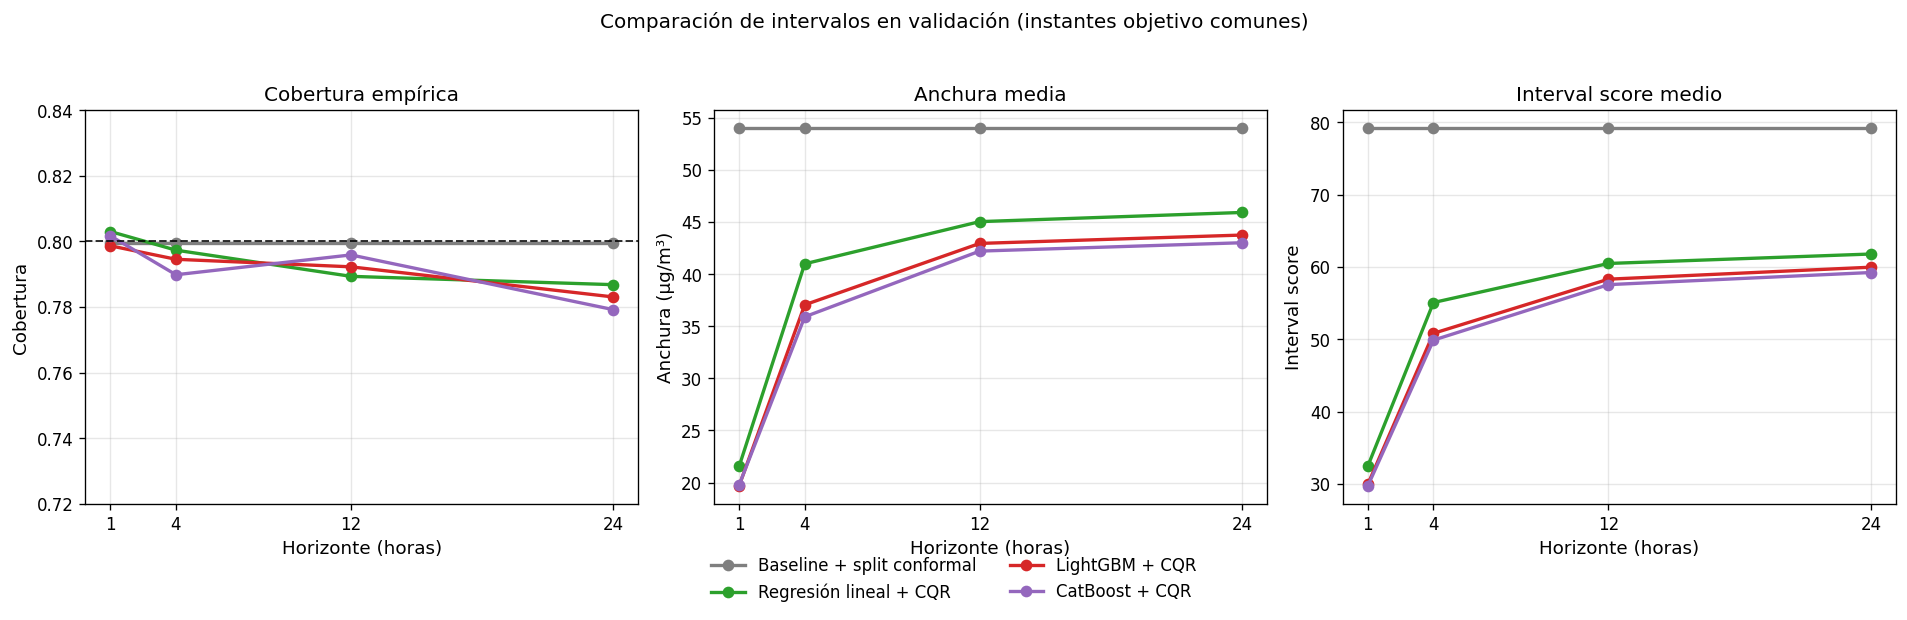

In [ ]:

# Figura 1: métricas principales que involucran a los instantes objetivo comunes

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)
plot_df = common_metrics_df.copy()

for model_id in MODEL_ORDER:
    model_df = plot_df.loc[plot_df["model"] == model_id].sort_values("horizon")
    meta = MODEL_REGISTRY[model_id]

    axes[0].plot(
        model_df["horizon"],
        model_df["empirical_coverage"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=meta["color"],
        label=meta["label"],
    )
    axes[1].plot(
        model_df["horizon"],
        model_df["mean_width"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=meta["color"],
        label=meta["label"],
    )
    axes[2].plot(
        model_df["horizon"],
        model_df["mean_interval_score"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=meta["color"],
        label=meta["label"],
    )

axes[0].axhline(NOMINAL_COVERAGE, linestyle="--", linewidth=1.2, color="black", alpha=0.8)
axes[0].set_title("Cobertura empírica")
axes[0].set_ylabel("Cobertura")
axes[0].set_ylim(0.72, max(0.84, plot_df["empirical_coverage"].max() + 0.01))

axes[1].set_title("Anchura media")
axes[1].set_ylabel("Anchura (µg/m³)")

axes[2].set_title("Interval score medio")
axes[2].set_ylabel("Interval score")

for ax in axes:
    ax.set_xlabel("Horizonte (horas)")
    ax.set_xticks(HORIZONS)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Comparación de las métricas obtenidas por los intervalos de predicción", y=1.03)
fig.tight_layout(rect=[0, 0.05, 1, 1])

figure_path = REPORTS_FIGURES_DIR / "fig_interval_metrics_validation_common.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {figure_path}")
plt.show()


Figura guardada en: c:\trabajo_github\reports\figures\fig_interval_tradeoff_validation_common.png


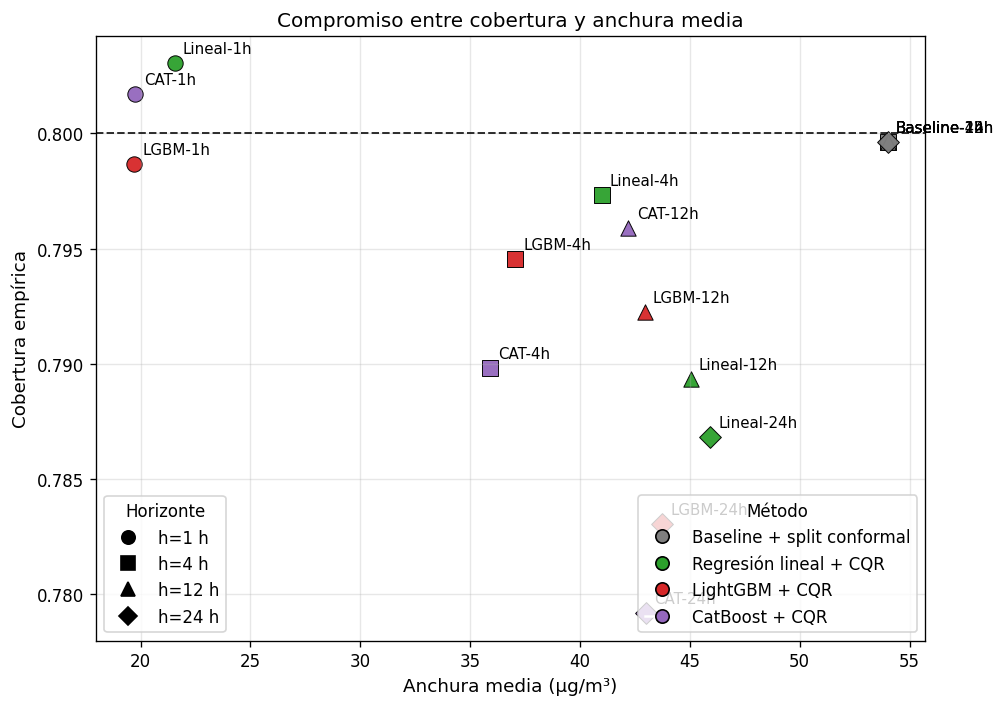

In [ ]:

# Figura 2: equilibrio entre cobertura y anchura media

fig, ax = plt.subplots(figsize=(8.5, 6))
plot_df = common_metrics_df.copy()

for model_id in MODEL_ORDER:
    model_df = plot_df.loc[plot_df["model"] == model_id].sort_values("horizon")
    color = MODEL_REGISTRY[model_id]["color"]
    short_name = MODEL_REGISTRY[model_id]["short_name"]

    for _, row in model_df.iterrows():
        horizon = int(row["horizon"])
        marker = HORIZON_MARKERS[horizon]
        ax.scatter(
            row["mean_width"],
            row["empirical_coverage"],
            s=85,
            color=color,
            marker=marker,
            alpha=0.95,
            edgecolor="black",
            linewidth=0.6,
        )
        ax.annotate(
            f"{short_name}-{horizon}h",
            xy=(row["mean_width"], row["empirical_coverage"]),
            xytext=(5, 6),
            textcoords="offset points",
            fontsize=9,
        )

ax.axhline(NOMINAL_COVERAGE, linestyle="--", linewidth=1.2, color="black", alpha=0.8)
ax.set_title("Equilibrio entre cobertura y anchura media")
ax.set_xlabel("Anchura media (µg/m³)")
ax.set_ylabel("Cobertura empírica")
ax.grid(True, alpha=0.3)

model_legend = [
    Line2D([0], [0], marker="o", color="w", label=MODEL_REGISTRY[m]["label"], markerfacecolor=MODEL_REGISTRY[m]["color"], markeredgecolor="black", markersize=8)
    for m in MODEL_ORDER
]

horizon_legend = [
    Line2D([0], [0], marker=HORIZON_MARKERS[h], color="black", linestyle="", label=f"h={h} h", markersize=8)
    for h in HORIZONS
]

legend1 = ax.legend(handles=model_legend, loc="lower right", frameon=True, title="Método")
ax.add_artist(legend1)
ax.legend(handles=horizon_legend, loc="lower left", frameon=True, title="Horizonte")

tradeoff_path = REPORTS_FIGURES_DIR / "fig_interval_tradeoff_validation_common.png"
fig.tight_layout()
fig.savefig(tradeoff_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {tradeoff_path}")
plt.show()


Figura guardada en: c:\trabajo_github\reports\figures\fig_interval_improvement_vs_baseline_validation_common.png


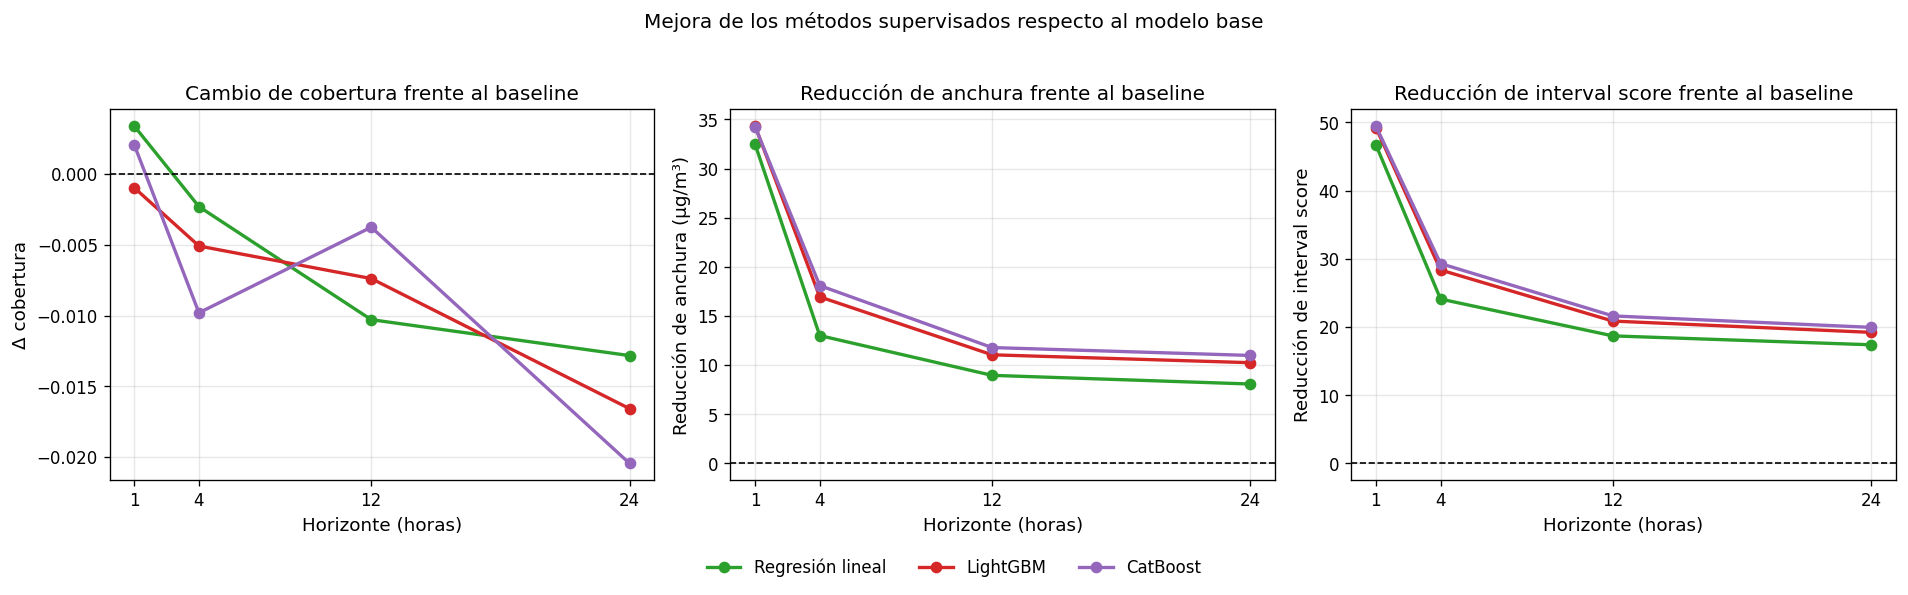

In [ ]:

# Figura 3: mejora respecto al modelo base
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True)
plot_df = improvement_vs_baseline_df.copy()
non_baseline_models = [m for m in MODEL_ORDER if m != "baseline_seasonal_naive"]

for model_id in non_baseline_models:
    model_df = plot_df.loc[plot_df["model"] == model_id].sort_values("horizon")
    meta = MODEL_REGISTRY[model_id]

    axes[0].plot(
        model_df["horizon"],
        model_df["delta_coverage_vs_baseline"],
        marker="o",
        linewidth=2,
        color=meta["color"],
        label=meta["display_name"],
    )
    axes[1].plot(
        model_df["horizon"],
        model_df["width_reduction_vs_baseline"],
        marker="o",
        linewidth=2,
        color=meta["color"],
        label=meta["display_name"],
    )
    axes[2].plot(
        model_df["horizon"],
        model_df["interval_score_reduction_vs_baseline"],
        marker="o",
        linewidth=2,
        color=meta["color"],
        label=meta["display_name"],
    )

axes[0].axhline(0, linestyle="--", color="black", linewidth=1)
axes[0].set_title("Cambio de cobertura frente al modelo base")
axes[0].set_ylabel("Δ cobertura")

axes[1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1].set_title("Reducción de anchura frente al modelo base")
axes[1].set_ylabel("Reducción de anchura (µg/m³)")

axes[2].axhline(0, linestyle="--", color="black", linewidth=1)
axes[2].set_title("Reducción de interval score frente al modelo base")
axes[2].set_ylabel("Reducción de interval score")

for ax in axes:
    ax.set_xlabel("Horizonte (horas)")
    ax.set_xticks(HORIZONS)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Mejora de los métodos supervisados respecto al modelo base", y=1.03)
fig.tight_layout(rect=[0, 0.05, 1, 1])

improvement_fig_path = REPORTS_FIGURES_DIR / "fig_interval_improvement_vs_baseline_validation_common.png"
fig.savefig(improvement_fig_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {improvement_fig_path}")
plt.show()



### Ejemplo visual de los intervalos: el modelo base frente al mejor método supervisado en \(h=24\)

Para completar la comparación numérica, se ofrece el siguiente ejemplo visual en el que el método supervisado se elige automáticamente como aquel que obtiene el mejor **interval score** en el horizonte de 24 horas dentro de la comparación principal.


Mejor método supervisado en h=24 h: CatBoost + CQR
Tabla de ejemplo guardada: c:\trabajo_github\reports\tables\interval_example_best_vs_baseline_h24.csv
Figura guardada en: c:\trabajo_github\reports\figures\fig_interval_zoom_best_vs_baseline_h24.png


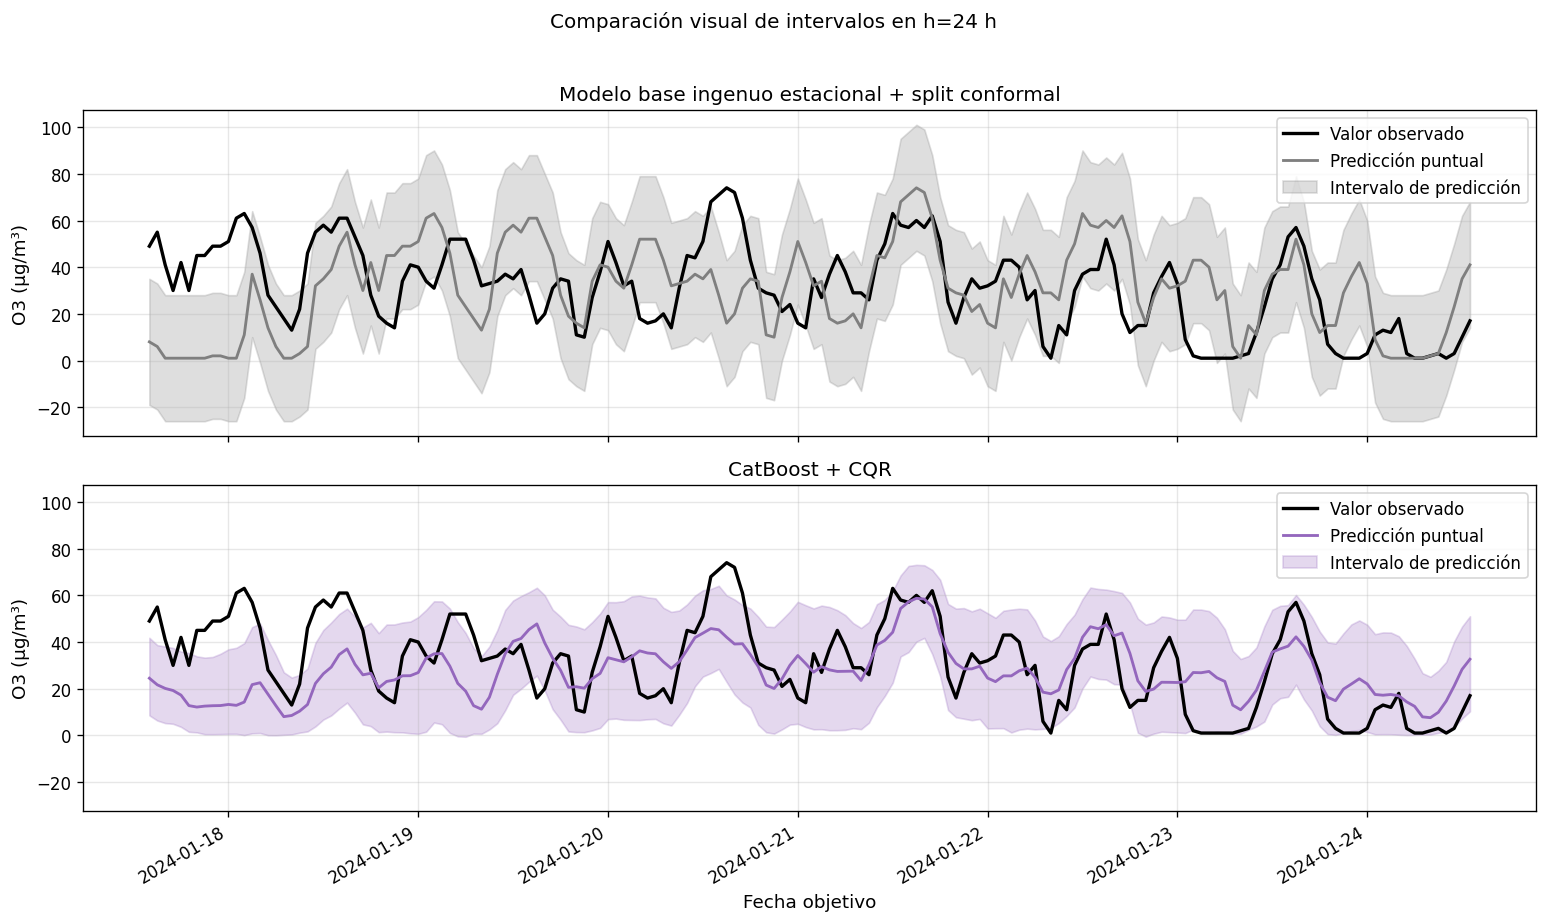

In [ ]:
# Figura 4: comparación visual del modelo base y el mejor método supervisado para h=24
# ==============================================================================
example_best_row = (
    common_metrics_df.loc[
        (common_metrics_df["horizon"] == EXAMPLE_HORIZON)
        & (common_metrics_df["model"] != "baseline_seasonal_naive")
    ]
    .sort_values(
        ["mean_interval_score", "coverage_abs_error", "mean_width"],
        ascending=[True, True, True],
    )
    .iloc[0]
)

best_supervised_model = example_best_row["model"]
print(
    f"Mejor método supervisado en h={EXAMPLE_HORIZON} h: "
    f"{MODEL_REGISTRY[best_supervised_model]['label']}"
)

baseline_example = common_intervals.loc[
    (common_intervals["model"] == "baseline_seasonal_naive")
    & (common_intervals["horizon"] == EXAMPLE_HORIZON)
].copy()

best_example = common_intervals.loc[
    (common_intervals["model"] == best_supervised_model)
    & (common_intervals["horizon"] == EXAMPLE_HORIZON)
].copy()

# Se restringe a los instantes comunes entre ambos para evitar huecos distintos.
shared_targets = sorted(
    set(baseline_example["target_timestamp"]).intersection(
        set(best_example["target_timestamp"])
    )
)

baseline_example = baseline_example.loc[
    baseline_example["target_timestamp"].isin(shared_targets)
].copy()

best_example = best_example.loc[
    best_example["target_timestamp"].isin(shared_targets)
].copy()

# Se selecciona un bloque continuo de fechas para mostrar el ejemplo visual.
baseline_block = select_continuous_block(baseline_example, n_hours=EXAMPLE_HOURS)
block_targets = set(baseline_block["target_timestamp"])

best_block = (
    best_example.loc[best_example["target_timestamp"].isin(block_targets)]
    .copy()
    .sort_values("target_timestamp")
)

# Se guarda también una tabla con los valores mostrados en la figura.
example_block_path = (
    REPORTS_TABLES_DIR / f"interval_example_best_vs_baseline_h{EXAMPLE_HORIZON:02d}.csv"
)

comparison_block_df = baseline_block[
    ["target_timestamp", "y_true", "y_pred_reference", "lower", "upper"]
].copy()

comparison_block_df = comparison_block_df.rename(
    columns={
        "y_pred_reference": "baseline_y_pred",
        "lower": "baseline_lower",
        "upper": "baseline_upper",
    }
).merge(
    best_block[
        ["target_timestamp", "y_pred_reference", "lower", "upper"]
    ].rename(
        columns={
            "y_pred_reference": "best_y_pred",
            "lower": "best_lower",
            "upper": "best_upper",
        }
    ),
    on="target_timestamp",
    how="left",
)

comparison_block_df.to_csv(example_block_path, index=False)
print(f"Tabla de ejemplo guardada: {example_block_path}")

# Se utiliza un rango común para ambas gráficas
y_values = pd.concat(
    [
        baseline_block["y_true"],
        baseline_block["y_pred_reference"],
        baseline_block["lower"],
        baseline_block["upper"],
        best_block["y_true"],
        best_block["y_pred_reference"],
        best_block["lower"],
        best_block["upper"],
    ],
    axis=0,
).dropna()

y_min = y_values.min()
y_max = y_values.max()

# Se añade un pequeño margen vertical para que la figura respire mejor.
y_margin = 0.05 * (y_max - y_min)
if y_margin == 0:
    y_margin = 1.0

common_ylim = (y_min - y_margin, y_max + y_margin)

# Se pinta la figura
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)

# Panel superior: el modelo base
axes[0].plot(
    baseline_block["target_timestamp"],
    baseline_block["y_true"],
    label="Valor observado",
    linewidth=2,
    color="black",
)

axes[0].plot(
    baseline_block["target_timestamp"],
    baseline_block["y_pred_reference"],
    label="Predicción puntual",
    linewidth=1.7,
    color=MODEL_REGISTRY["baseline_seasonal_naive"]["color"],
)

axes[0].fill_between(
    baseline_block["target_timestamp"],
    baseline_block["lower"],
    baseline_block["upper"],
    alpha=0.25,
    color=MODEL_REGISTRY["baseline_seasonal_naive"]["color"],
    label="Intervalo de predicción",
)

axes[0].set_title("Modelo base ingenuo estacional + split conformal")
axes[0].set_ylabel("O3 (µg/m³)")
axes[0].set_ylim(common_ylim)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")

# Panel de abajo: el mejor método supervisado.
axes[1].plot(
    best_block["target_timestamp"],
    best_block["y_true"],
    label="Valor observado",
    linewidth=2,
    color="black",
)

axes[1].plot(
    best_block["target_timestamp"],
    best_block["y_pred_reference"],
    label="Predicción puntual",
    linewidth=1.7,
    color=MODEL_REGISTRY[best_supervised_model]["color"],
)

axes[1].fill_between(
    best_block["target_timestamp"],
    best_block["lower"],
    best_block["upper"],
    alpha=0.25,
    color=MODEL_REGISTRY[best_supervised_model]["color"],
    label="Intervalo de predicción",
)

axes[1].set_title(MODEL_REGISTRY[best_supervised_model]["label"])
axes[1].set_ylabel("O3 (µg/m³)")
axes[1].set_xlabel("Fecha objetivo")
axes[1].set_ylim(common_ylim)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

fig.suptitle(f"Comparación visual de intervalos en h={EXAMPLE_HORIZON} h", y=1.02)
fig.autofmt_xdate()
fig.tight_layout()

zoom_path = REPORTS_FIGURES_DIR / f"fig_interval_zoom_best_vs_baseline_h{EXAMPLE_HORIZON:02d}.png"
fig.savefig(zoom_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada en: {zoom_path}")
plt.show()


## Conclusión preliminar

La siguiente tabla hace un resumen de la selección preliminar por horizonte de acuerdo con el interval score calculado sobre los instantes objetivo comunes.


In [ ]:

# Resumen de la selección preliminar

selection_summary_df = best_method_by_horizon_df[
    [
        "horizon",
        "label",
        "n_samples",
        "empirical_coverage",
        "mean_width",
        "mean_interval_score",
        "coverage_error",
    ]
].copy()
selection_summary_df = selection_summary_df.rename(
    columns={
        "label": "selected_method",
        "n_samples": "n_common_samples",
    }
)

# Se añade también el mejor método global según la media del interval score.
overall_ranking_df = (
    common_metrics_df.groupby(["model", "label"], as_index=False)
    .agg(
        mean_interval_score_across_horizons=("mean_interval_score", "mean"),
        mean_width_across_horizons=("mean_width", "mean"),
        mean_coverage_across_horizons=("empirical_coverage", "mean"),
    )
    .sort_values(["mean_interval_score_across_horizons", "mean_width_across_horizons"], ascending=[True, True])
    .reset_index(drop=True)
)
overall_ranking_df["global_rank"] = np.arange(1, len(overall_ranking_df) + 1)

selection_summary_path = REPORTS_TABLES_DIR / "interval_selection_summary.csv"
overall_ranking_path = REPORTS_TABLES_DIR / "interval_overall_ranking.csv"
selection_summary_df.to_csv(selection_summary_path, index=False)
overall_ranking_df.to_csv(overall_ranking_path, index=False)

print("Selección preliminar por horizonte:")
display(selection_summary_df)

print("Ranking global por media del interval score:")
display(overall_ranking_df)

print(f"Tabla guardada: {selection_summary_path}")
print(f"Tabla guardada: {overall_ranking_path}")


Selección preliminar por horizonte:


,horizon,selected_method,n_common_samples,empirical_coverage,mean_width,mean_interval_score,coverage_error
0,1,CatBoost + CQR,8265,0.802,19.759,29.740,0.002
1,4,CatBoost + CQR,8265,0.790,35.902,49.886,-0.010
2,12,CatBoost + CQR,8265,0.796,42.207,57.559,-0.004
3,24,CatBoost + CQR,8265,0.779,43.010,59.237,-0.021


Ranking global por media del interval score:


,model,label,mean_interval_score_across_horizons,mean_width_across_horizons,mean_coverage_across_horizons,global_rank
0,catboost,CatBoost + CQR,49.106,35.219,0.792,1
1,lightgbm,LightGBM + CQR,49.768,35.857,0.792,2
2,linear_regression,Regresión lineal + CQR,52.462,38.371,0.794,3
3,baseline_seasonal_naive,Baseline + split conformal,79.195,54.000,0.800,4


Tabla guardada: c:\trabajo_github\reports\tables\interval_selection_summary.csv
Tabla guardada: c:\trabajo_github\reports\tables\interval_overall_ranking.csv


In [ ]:

# Comprobaciones finales
# ==============================================================================
assert not validation_intervals.empty, "No se han cargado los intervalos de validación."
assert not available_metrics_df.empty, "La tabla de métricas disponibles está vacía."
assert not common_metrics_df.empty, "La tabla de métricas comunes está vacía."
assert len(common_metrics_df) == len(MODEL_ORDER) * len(HORIZONS), "Faltan combinaciones modelo-horizonte en la comparación principal."
assert (common_metrics_df["n_samples"] > 0).all(), "Algún método carece de observaciones comunes."
assert (comparison_target_counts_df["n_common_targets"] > 0).all(), "Algún horizonte no tiene instantes comunes."

expected_figure_paths = [
    REPORTS_FIGURES_DIR / "fig_interval_metrics_validation_common.png",
    REPORTS_FIGURES_DIR / "fig_interval_tradeoff_validation_common.png",
    REPORTS_FIGURES_DIR / "fig_interval_improvement_vs_baseline_validation_common.png",
    REPORTS_FIGURES_DIR / f"fig_interval_zoom_best_vs_baseline_h{EXAMPLE_HORIZON:02d}.png",
]
missing_figures = [path for path in expected_figure_paths if not path.exists()]
assert not missing_figures, f"Faltan figuras: {missing_figures}"

print("Comprobaciones finales superadas correctamente.")
print("- Se han comparado todos los métodos sobre validación 2024.")
print("- La comparación principal se ha construido sobre instantes objetivo comunes.")
print("- Se han guardado tablas comparativas y figuras para la memoria.")
print("- Queda preparado el material para la redacción de resultados de intervalos.")


Comprobaciones finales superadas correctamente.
- Se han comparado todos los métodos sobre validación 2024.
- La comparación principal se ha construido sobre instantes objetivo comunes.
- Se han guardado tablas comparativas y figuras para la memoria.
- Queda preparado el material para la redacción de resultados de intervalos.
